<a href="https://colab.research.google.com/github/advitya1417-alt/Fraud-detector/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

How many transactions do you want to enter? 5
Transaction 1 - Amount: 20000
Transaction 1 - Is Fraud? (0 = No, 1 = Yes): 1
Transaction 2 - Amount: 30000
Transaction 2 - Is Fraud? (0 = No, 1 = Yes): 0
Transaction 3 - Amount: 446366
Transaction 3 - Is Fraud? (0 = No, 1 = Yes): 1
Transaction 4 - Amount: 66565
Transaction 4 - Is Fraud? (0 = No, 1 = Yes): 0
Transaction 5 - Amount: 65656767
Transaction 5 - Is Fraud? (0 = No, 1 = Yes): 1


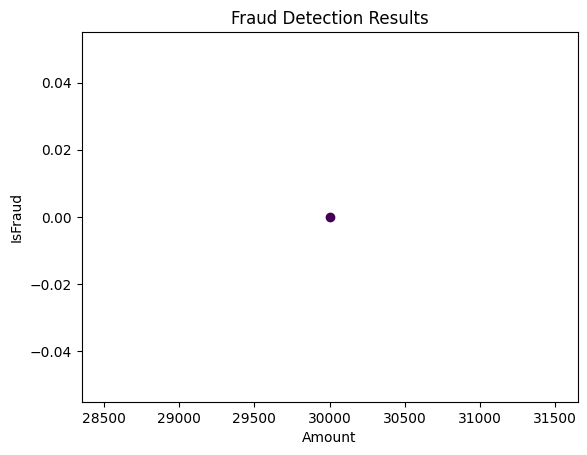


Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

def get_user_data():
    """Collect transaction amounts and fraud labels from user input."""
    amounts = []
    fraud_labels = []

    n = int(input("How many transactions do you want to enter? "))

    for i in range(n):
        while True:
            try:
                amt = float(input(f"Transaction {i+1} - Amount: "))
                break
            except ValueError:
                print("Please enter a valid number for amount.")

        while True:
            label = input(f"Transaction {i+1} - Is Fraud? (0 = No, 1 = Yes): ").strip()
            if label in ('0', '1'):
                break
            print("Please enter 0 or 1.")

        amounts.append(amt)
        fraud_labels.append(int(label))

    return pd.DataFrame({'Amount': amounts, 'IsFraud': fraud_labels})


# Collect dataset from user
df = get_user_data()

if df['IsFraud'].sum() == 0:
    print("\nWarning: no fraud cases entered — evaluation metrics will be meaningless.\n")

# Split the dataset into training and testing sets
test_frac = 0.2 if len(df) >= 5 else 0.5  # avoid empty test set on tiny inputs
X_train, X_test, y_train, y_test = train_test_split(
    df[['Amount']], df['IsFraud'], test_size=test_frac, random_state=42
)

# Train an Isolation Forest model
contamination = max(min(df['IsFraud'].mean(), 0.5), 0.01)  # match rough fraud rate
model = IsolationForest(contamination=contamination, random_state=42)
model.fit(X_train)

# Make predictions on the test set
raw_predictions = model.predict(X_test)

# Map IsolationForest's -1/1 output to your 1/0 fraud labels
# -1 (outlier) -> 1 (fraud), 1 (inlier) -> 0 (not fraud)
predictions = pd.Series(raw_predictions).map({1: 0, -1: 1}).values

# Visualize the results
plt.scatter(X_test, y_test, c=predictions, cmap='viridis')
plt.xlabel('Amount')
plt.ylabel('IsFraud')
plt.title('Fraud Detection Results')
plt.show()

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
print(f'\nAccuracy: {accuracy * 100:.2f}%\n')

print('Classification Report:')
print(classification_report(y_test, predictions, zero_division=0))